# Car Price Prediction with Machine Learning
**Models:** Random Forest + Neural Network , **Evaluation:** Regression + Classification (Test Data)

## Cell 1 — Library Import

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('✅ All libraries imported!')
print(f'TensorFlow: {tf.__version__}')

✅ All libraries imported!
TensorFlow: 2.19.0


## Cell 2 — Dataset Load & Preview

In [6]:
df = pd.read_csv('/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nColumn info:')
print(df.info())

Shape: (301, 9)

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


## Cell 3 — Data Cleaning & Preprocessing

In [7]:
print('Null values:')
print(df.isnull().sum())
df.dropna(inplace=True)

# Car age is more meaningful than year
df['Car_Age'] = 2024 - df['Year']
df.drop(columns=['Year', 'Car_Name'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    df[col] = le.fit_transform(df[col])

print('\nCleaned dataset shape:', df.shape)
display(df.head())

Null values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Cleaned dataset shape: (301, 8)


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,10
1,4.75,9.54,43000,1,0,1,0,11
2,7.25,9.85,6900,2,0,1,0,7
3,2.85,4.15,5200,2,0,1,0,13
4,4.60,6.87,42450,1,0,1,0,10


## Cell 4 — EDA: Statistical Summary & Distributions

Statistical Summary:


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,1.787375,0.352159,0.867110,0.043189,10.372093
std,5.082812,8.642584,38886.883882,0.425801,0.478439,0.340021,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,0.000000,0.000000,0.000000,6.000000
25%,0.900000,1.200000,15000.000000,2.000000,0.000000,1.000000,0.000000,8.000000
50%,3.600000,6.400000,32000.000000,2.000000,0.000000,1.000000,0.000000,10.000000
75%,6.000000,9.900000,48767.000000,2.000000,1.000000,1.000000,0.000000,12.000000
max,35.000000,92.600000,500000.000000,2.000000,1.000000,1.000000,3.000000,21.000000


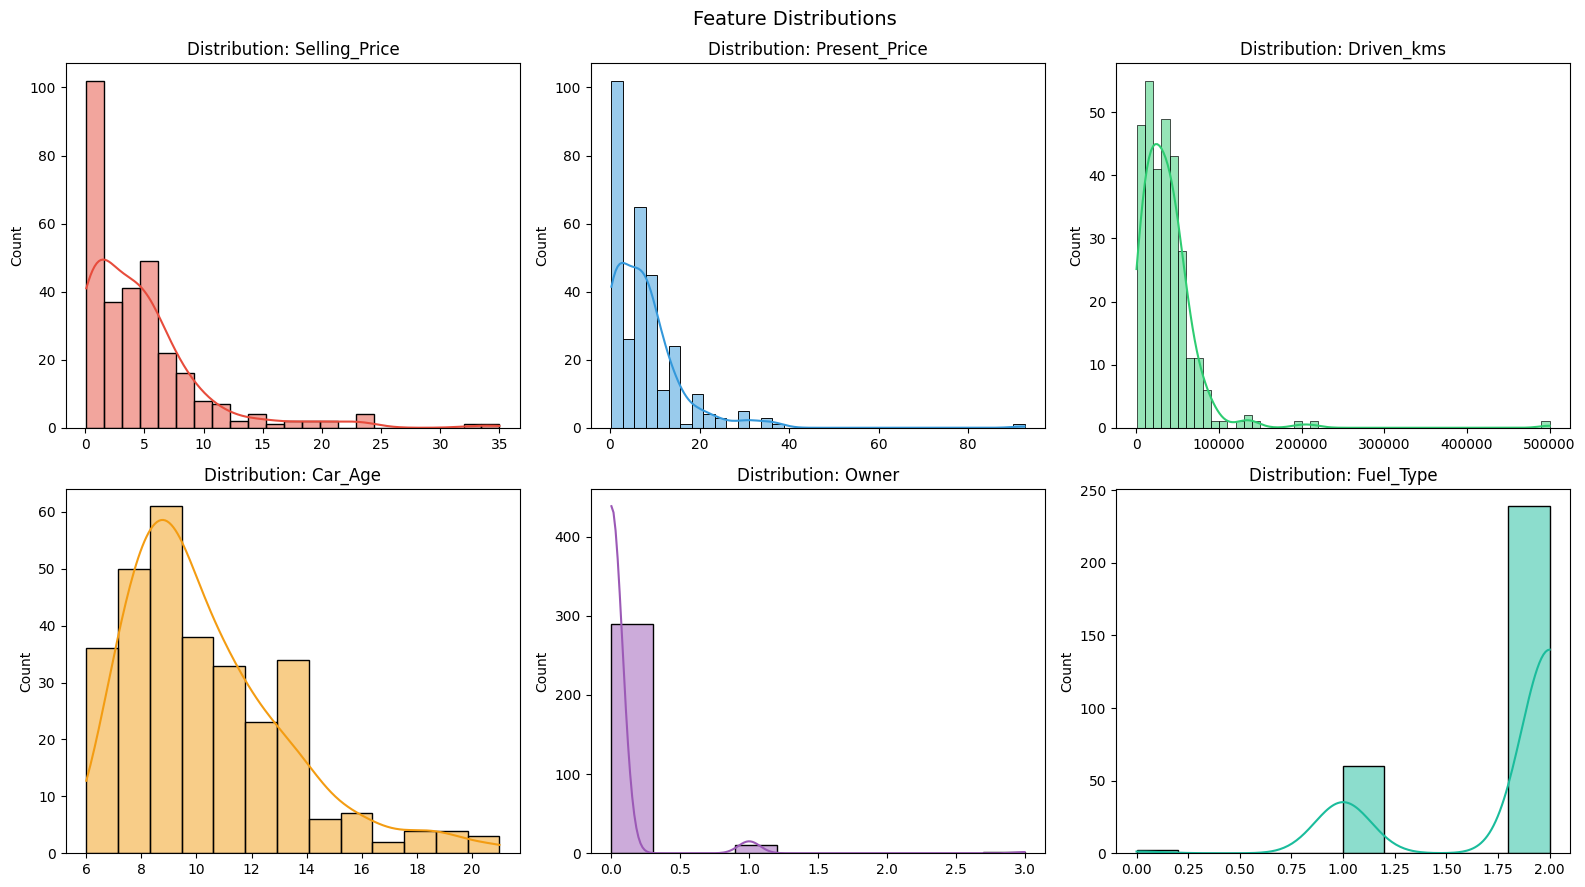

In [8]:
print('Statistical Summary:')
display(df.describe())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['Selling_Price', 'Present_Price', 'Driven_kms', 'Car_Age', 'Owner', 'Fuel_Type']
colors   = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for ax, col, color in zip(axes.flatten(), num_cols, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    ax.set_title(f'Distribution: {col}')
    ax.set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 5 — EDA: Correlation Heatmap

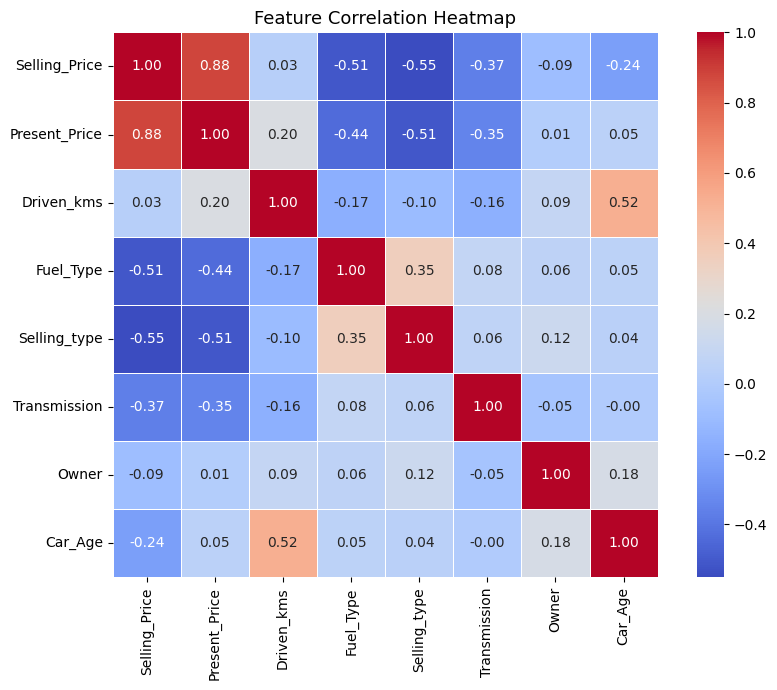

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 6 — EDA: Key Visual Insights

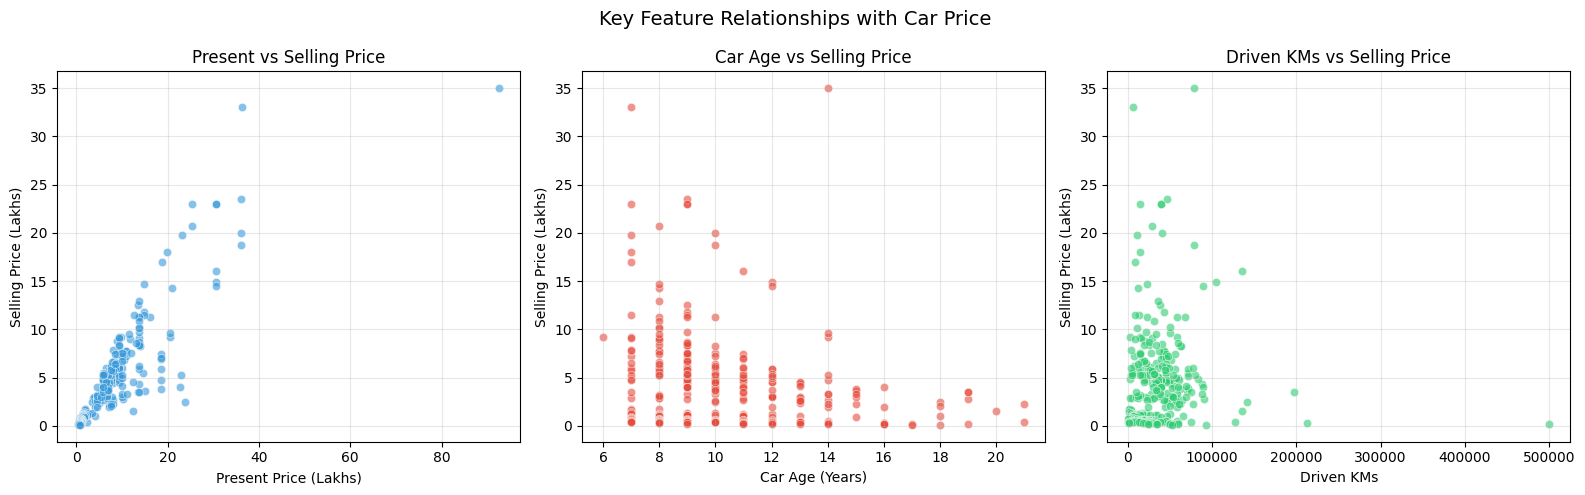

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Selling Price vs Present Price
axes[0].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.6, color='#3498db', edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Present Price (Lakhs)')
axes[0].set_ylabel('Selling Price (Lakhs)')
axes[0].set_title('Present vs Selling Price')
axes[0].grid(True, alpha=0.3)

# Selling Price vs Car Age
axes[1].scatter(df['Car_Age'], df['Selling_Price'], alpha=0.6, color='#e74c3c', edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Car Age (Years)')
axes[1].set_ylabel('Selling Price (Lakhs)')
axes[1].set_title('Car Age vs Selling Price')
axes[1].grid(True, alpha=0.3)

# Selling Price vs Driven KMs
axes[2].scatter(df['Driven_kms'], df['Selling_Price'], alpha=0.6, color='#2ecc71', edgecolors='white', linewidth=0.5)
axes[2].set_xlabel('Driven KMs')
axes[2].set_ylabel('Selling Price (Lakhs)')
axes[2].set_title('Driven KMs vs Selling Price')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Key Feature Relationships with Car Price', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 7 — Feature Engineering + Train/Test Split

In [11]:
features = ['Present_Price', 'Driven_kms', 'Fuel_Type',
            'Selling_type', 'Transmission', 'Owner', 'Car_Age']

X = df[features]
y_reg = df['Selling_Price']   # Regression target (actual price)

# Classification target: price range
def price_label(p):
    if p < 3:   return 0   # Low
    elif p < 7: return 1   # Mid
    else:       return 2   # High

y_cls = df['Selling_Price'].apply(price_label)

print('Price class distribution:')
print(y_cls.value_counts().rename({0:'Low (<3L)', 1:'Mid (3-7L)', 2:'High (>7L)'}))

# Train/Test split — same split for both regression & classification
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _,           y_train_cls, y_test_cls  = train_test_split(X, y_cls, test_size=0.2, random_state=42)

print(f'\nTrain samples : {X_train.shape[0]}')
print(f'Test samples  : {X_test.shape[0]}')
print(f'Features      : {features}')

Price class distribution:
Selling_Price
Low (<3L)     131
Mid (3-7L)    109
High (>7L)     61
Name: count, dtype: int64

Train samples : 240
Test samples  : 61
Features      : ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


## Cell 8 — Model 1: Random Forest Regressor (Test Data)

=== Random Forest Regressor — Test Data ===
MAE  : 0.6386 Lakhs
RMSE : 0.9742 Lakhs
R²   : 0.9588  (95.88% accuracy)


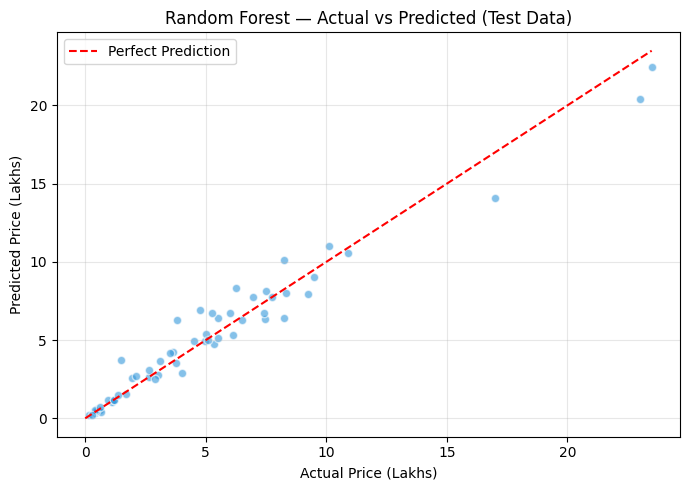

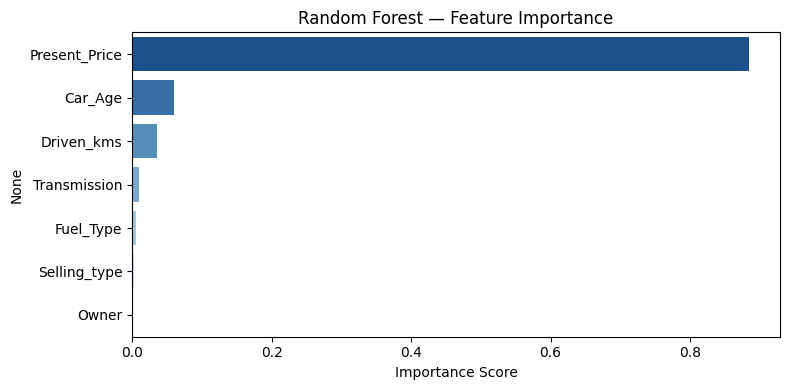

In [12]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_reg.fit(X_train, y_train_reg)

y_pred_rf_reg = rf_reg.predict(X_test)

rf_mae  = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
rf_r2   = r2_score(y_test_reg, y_pred_rf_reg)

print('=== Random Forest Regressor — Test Data ===')
print(f'MAE  : {rf_mae:.4f} Lakhs')
print(f'RMSE : {rf_rmse:.4f} Lakhs')
print(f'R²   : {rf_r2:.4f}  ({rf_r2*100:.2f}% accuracy)')

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.6, color='#3498db', edgecolors='white')
plt.plot([0, y_test_reg.max()], [0, y_test_reg.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Random Forest — Actual vs Predicted (Test Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature Importance
importance = pd.Series(rf_reg.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Cell 9 — Random Forest: Classification Report + Confusion Matrix (Test Data)

Random Forest Classification Accuracy: 85.25%

=== Random Forest Classification Report (Test Data) ===
              precision    recall  f1-score   support

         Low       0.96      0.92      0.94        26
         Mid       0.77      0.81      0.79        21
        High       0.79      0.79      0.79        14

    accuracy                           0.85        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.86      0.85      0.85        61



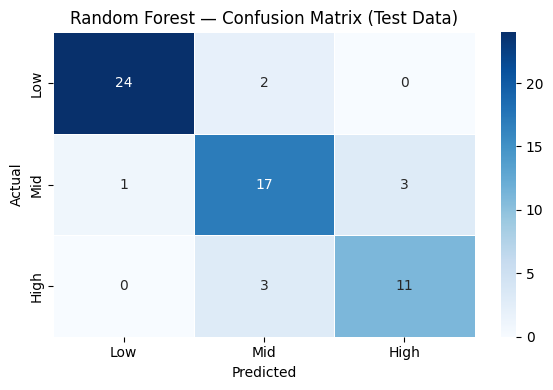

In [13]:
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_cls.fit(X_train, y_train_cls)

y_pred_rf_cls = rf_cls.predict(X_test)
rf_cls_acc = accuracy_score(y_test_cls, y_pred_rf_cls)

print(f'Random Forest Classification Accuracy: {rf_cls_acc*100:.2f}%')
print('\n=== Random Forest Classification Report (Test Data) ===')
print(classification_report(y_test_cls, y_pred_rf_cls, target_names=['Low','Mid','High']))

plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test_cls, y_pred_rf_cls)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Mid','High'],
            yticklabels=['Low','Mid','High'], linewidths=0.5)
plt.title('Random Forest — Confusion Matrix (Test Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Cell 10 — Neural Network: Data Scaling + Build

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# One-hot for classification output
y_train_cat = keras.utils.to_categorical(y_train_cls, num_classes=3)
y_test_cat  = keras.utils.to_categorical(y_test_cls,  num_classes=3)

nn_model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
nn_model.summary()

I0000 00:00:1779364546.026132      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,227 (47.76 KB)

 Trainable params: 11,843 (46.26 KB)

 Non-trainable params: 384 (1.50 KB)

## Cell 11 — Neural Network: Train with Validation (Epochs)

In [15]:
history = nn_model.fit(
    X_train_sc, y_train_cat,
    epochs=80,
    batch_size=16,
    validation_data=(X_test_sc, y_test_cat),
    verbose=1
)

print(f'\nFinal Train Accuracy : {history.history["accuracy"][-1]*100:.2f}%')
print(f'Final Test  Accuracy : {history.history["val_accuracy"][-1]*100:.2f}%')

Epoch 1/80


I0000 00:00:1779364549.188528     133 service.cc:152] XLA service 0x7e000c0028f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779364549.188569     133 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779364549.590208     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/15 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.4375 - loss: 1.3274

I0000 00:00:1779364551.505561     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.5197 - loss: 1.0616 - val_accuracy: 0.6557 - val_loss: 0.9900
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7195 - loss: 0.6188 - val_accuracy: 0.7049 - val_loss: 0.8938
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8138 - loss: 0.5146 - val_accuracy: 0.6885 - val_loss: 0.8286
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7815 - loss: 0.5196 - val_accuracy: 0.6721 - val_loss: 0.7697
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8839 - loss: 0.3684 - val_accuracy: 0.6557 - val_loss: 0.7274
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8494 - loss: 0.3451 - val_accuracy: 0.6721 - val_loss: 0.6862
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8412 - loss: 0.3730 - val_accuracy: 0.7377 - val_loss: 0.6474
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8538 - loss: 0.3581 - val_accuracy: 0.7869 - val_loss: 0.6081
Ep

## Cell 12 — Neural Network: Accuracy & Loss Curve (Train vs Test)

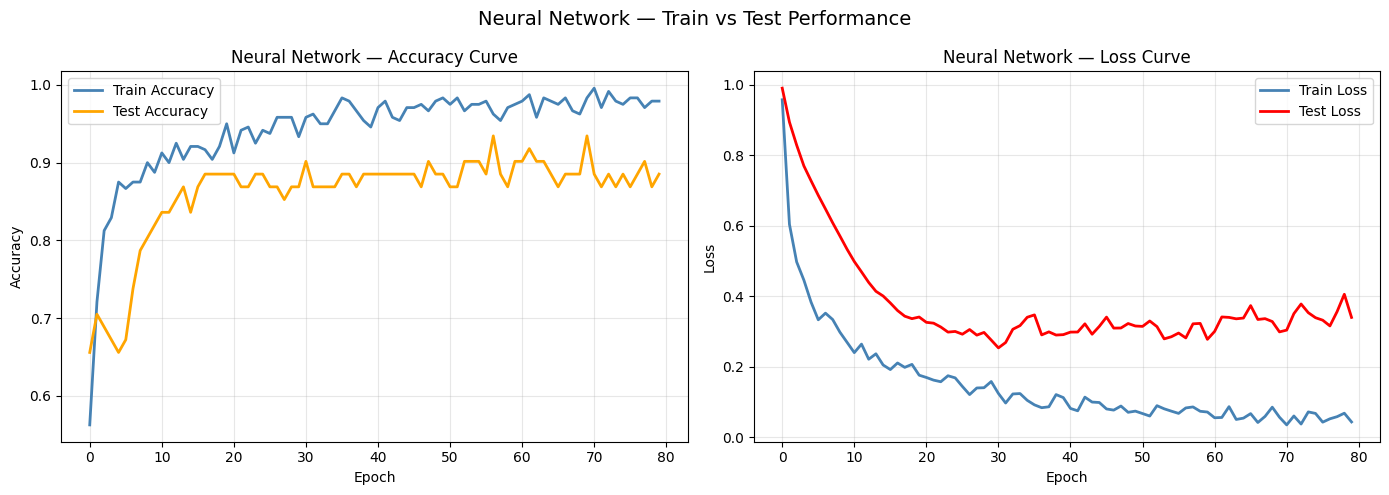

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Test Accuracy',  color='orange',    linewidth=2)
ax1.set_title('Neural Network — Accuracy Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Test Loss',  color='red',       linewidth=2)
ax2.set_title('Neural Network — Loss Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Neural Network — Train vs Test Performance', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 13 — Neural Network: Classification Report + Confusion Matrix (Test Data)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 68.5700 - mae: 6.0932 - val_loss: 44.0811 - val_mae: 4.7094
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 51.6179 - mae: 5.3461 - val_loss: 40.5532 - val_mae: 4.4673
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 39.7741 - mae: 4.6277 - val_loss: 35.7906 - val_mae: 4.1841
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28.2991 - mae: 3.8087 - val_loss: 30.2031 - val_mae: 3.8297
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.7075 - mae: 3.0730 - val_loss: 24.2629 - val_mae: 3.4099
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.9169 - mae: 2.4839 - val_loss: 19.1483 - val_mae: 2.9937
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9527 - mae: 1.8902 - val_loss: 15.5093 - val_mae: 2.6421
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.8750 - mae: 1.7253 - val_loss: 13.5645 - val_mae: 2.4301
Epoch 9/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss:

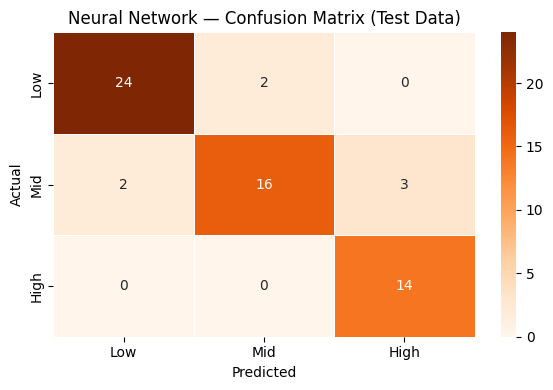

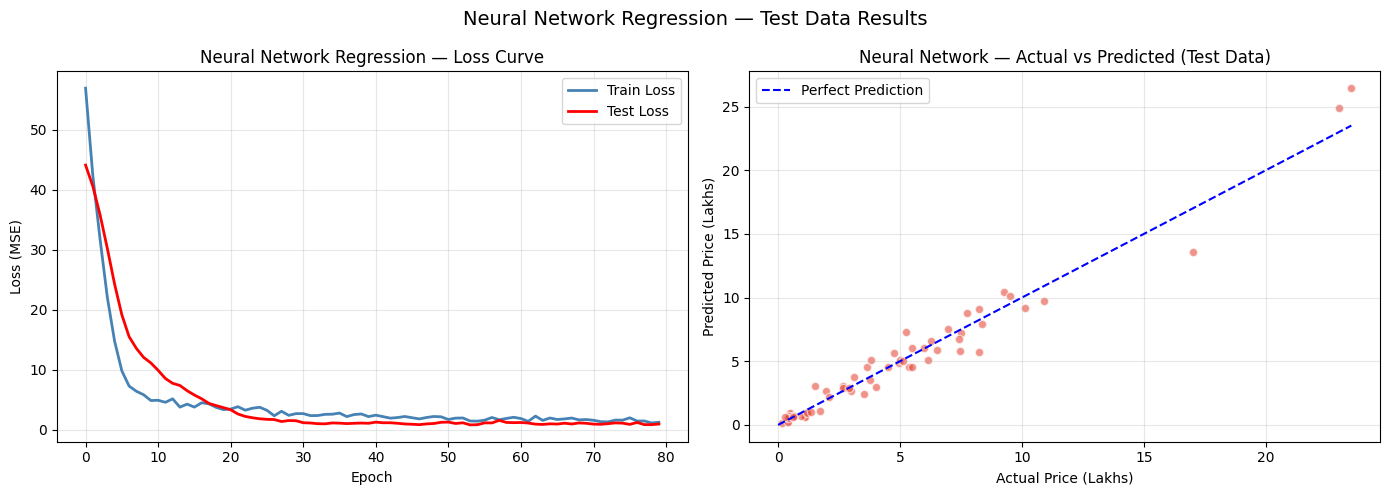

In [21]:
nn_reg_model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

nn_reg_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
nn_reg_model.summary()

history_reg = nn_reg_model.fit(
    X_train_sc, y_train_reg,
    epochs=80,
    batch_size=16,
    validation_data=(X_test_sc, y_test_reg),
    verbose=1
)

y_pred_nn_reg = nn_reg_model.predict(X_test_sc).flatten()

nn_mae  = mean_absolute_error(y_test_reg, y_pred_nn_reg)
nn_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_nn_reg))
nn_r2   = r2_score(y_test_reg, y_pred_nn_reg)

print('=== Neural Network Regressor — Test Data ===')
print(f'MAE  : {nn_mae:.4f} Lakhs')
print(f'RMSE : {nn_rmse:.4f} Lakhs')
print(f'R²   : {nn_r2:.4f}  ({nn_r2*100:.2f}% accuracy)')
nn_acc = accuracy_score(y_true_nn, y_pred_nn)
print(f'Neural Network Test Accuracy: {nn_acc*100:.2f}%')

print('\n=== Neural Network Classification Report (Test Data) ===')
print(classification_report(y_true_nn, y_pred_nn, target_names=['Low','Mid','High']))

plt.figure(figsize=(6, 4))
cm_nn = confusion_matrix(y_true_nn, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low','Mid','High'],
            yticklabels=['Low','Mid','High'], linewidths=0.5)
plt.title('Neural Network — Confusion Matrix (Test Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_reg.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(history_reg.history['val_loss'], label='Test Loss',  color='red',       linewidth=2)
ax1.set_title('Neural Network Regression — Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(y_test_reg, y_pred_nn_reg, alpha=0.6, color='#e74c3c', edgecolors='white')
ax2.plot([0, y_test_reg.max()], [0, y_test_reg.max()], 'b--', linewidth=1.5, label='Perfect Prediction')
ax2.set_xlabel('Actual Price (Lakhs)')
ax2.set_ylabel('Predicted Price (Lakhs)')
ax2.set_title('Neural Network — Actual vs Predicted (Test Data)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Neural Network Regression — Test Data Results', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 14 — Final Model Comparison


     REGRESSION RESULTS (Test Data)           
         Model    MAE   RMSE     R²
 Random Forest 0.6386 0.9742 0.9588
Neural Network 0.6823 0.9828 0.9581

   CLASSIFICATION ACCURACY (Test Data)        
         Model Test Accuracy
 Random Forest        85.25%
Neural Network        88.52%


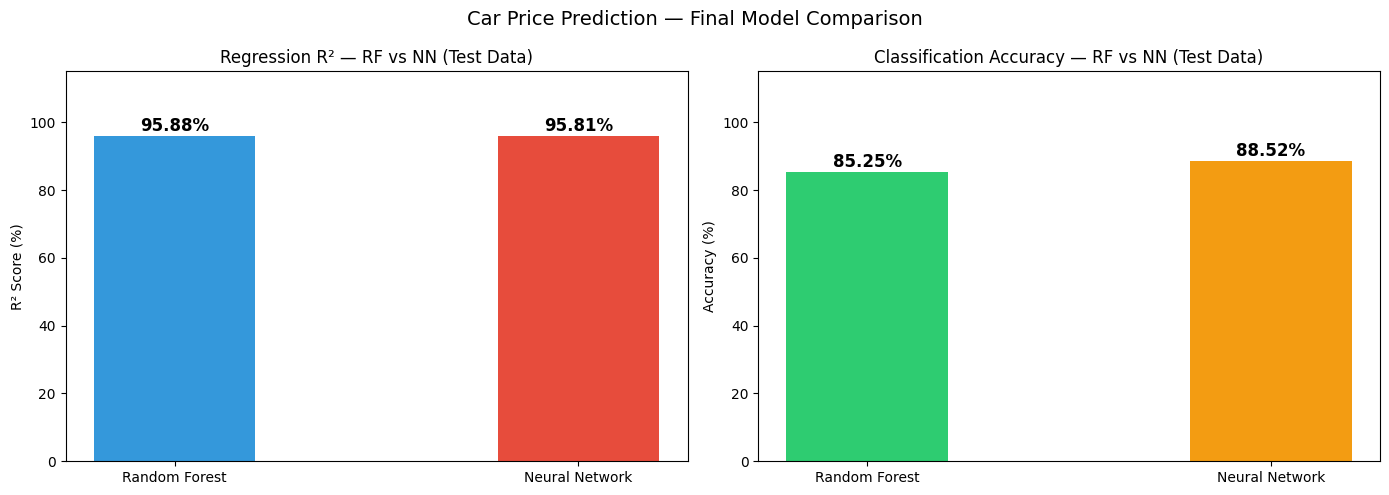


=== KEY INSIGHTS ===
1. Present_Price is the strongest predictor of car selling price.
2. Older cars and high driven KMs tend to have lower selling prices.
3. Diesel cars generally sell at higher prices than Petrol/CNG.
4. Automatic transmission cars command a premium over manual.


In [22]:
print('\n================================================')
print('     REGRESSION RESULTS (Test Data)           ')
print('================================================')
reg_results = pd.DataFrame({
    'Model' : ['Random Forest', 'Neural Network'],
    'MAE'   : [round(rf_mae,  4), round(nn_mae,  4)],
    'RMSE'  : [round(rf_rmse, 4), round(nn_rmse, 4)],
    'R²'    : [round(rf_r2,   4), round(nn_r2,   4)]
})
print(reg_results.to_string(index=False))

print('\n================================================')
print('   CLASSIFICATION ACCURACY (Test Data)        ')
print('================================================')
cls_results = pd.DataFrame({
    'Model'        : ['Random Forest', 'Neural Network'],
    'Test Accuracy': [f'{rf_cls_acc*100:.2f}%', f'{nn_acc*100:.2f}%']
})
print(cls_results.to_string(index=False))
print('================================================')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
bars1 = axes[0].bar(['Random Forest', 'Neural Network'],
                    [rf_r2*100, nn_r2*100],
                    color=['#3498db','#e74c3c'], width=0.4)
axes[0].set_ylabel('R² Score (%)')
axes[0].set_title('Regression R² — RF vs NN (Test Data)')
axes[0].set_ylim(0, 115)
for bar, val in zip(bars1, [rf_r2*100, nn_r2*100]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

# Classification accuracy comparison
bars2 = axes[1].bar(['Random Forest', 'Neural Network'],
                    [rf_cls_acc*100, nn_acc*100],
                    color=['#2ecc71','#f39c12'], width=0.4)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Classification Accuracy — RF vs NN (Test Data)')
axes[1].set_ylim(0, 115)
for bar, val in zip(bars2, [rf_cls_acc*100, nn_acc*100]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Car Price Prediction — Final Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print('\n=== KEY INSIGHTS ===')
print('1. Present_Price is the strongest predictor of car selling price.')
print('2. Older cars and high driven KMs tend to have lower selling prices.')
print('3. Diesel cars generally sell at higher prices than Petrol/CNG.')
print('4. Automatic transmission cars command a premium over manual.')